In [2]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
from huggingface_hub import hf_hub_download
from sklearn.metrics import f1_score, precision_score, recall_score, fbeta_score, confusion_matrix

HF_TOKEN = os.getenv("HF_TOKEN")
REPO_ID = "hannusia123123/si-oof"
FILE_ROBERTA = "oof_roberta.pkl"
FILE_ELECTRA = "oof_electra.pkl"

print("☁️ Downloading data directly from Hugging Face (or using cache)...")
roberta_path = hf_hub_download(repo_id=REPO_ID, filename=FILE_ROBERTA, repo_type="dataset", token=HF_TOKEN)
electra_path = hf_hub_download(repo_id=REPO_ID, filename=FILE_ELECTRA, repo_type="dataset", token=HF_TOKEN)

print("📦 Loading data into memory...")
with open(roberta_path, "rb") as f:
    oof_rob = pickle.load(f)
with open(electra_path, "rb") as f:
    oof_ele = pickle.load(f)

rob_by_article = defaultdict(list)
for x in oof_rob: 
    rob_by_article[x["article_id"]].append(x)
ele_by_article = defaultdict(list)
for x in oof_ele: 
    ele_by_article[x["article_id"]].append(x)

unique_articles = list(rob_by_article.keys())

y_true_all = []
p_rob_all = []
p_ele_all = []
article_char_bounds = {} 
current_idx = 0

print("🔄 Projecting token probabilities to Character Level (this takes a few seconds)...")

for art_id in unique_articles:
    rob_windows = rob_by_article[art_id]
    ele_windows = ele_by_article[art_id]

    max_char = max([end for w in rob_windows + ele_windows for start, end in w["offset_mapping"]] + [0])
    if max_char == 0: 
        continue

    c_prob_rob = np.zeros((max_char, 3))
    c_count_rob = np.zeros(max_char)
    c_prob_ele = np.zeros((max_char, 3))
    c_count_ele = np.zeros(max_char)
    c_labels = np.full(max_char, -100, dtype=int)

    for w in rob_windows:
        for i, (s, e) in enumerate(w["offset_mapping"]):
            if s == e: 
                continue
            c_prob_rob[s:e] += w["probs"][i]
            c_count_rob[s:e] += 1
            if w["labels"][i] != -100: 
                c_labels[s:e] = w["labels"][i]

    for w in ele_windows:
        for i, (s, e) in enumerate(w["offset_mapping"]):
            if s == e: 
                continue
            c_prob_ele[s:e] += w["probs"][i]
            c_count_ele[s:e] += 1

    mask_rob = c_count_rob > 0
    c_prob_rob[mask_rob] /= c_count_rob[mask_rob][:, None]
    
    mask_ele = c_count_ele > 0
    c_prob_ele[mask_ele] /= c_count_ele[mask_ele][:, None]

    valid_mask = (c_labels != -100) & mask_rob & mask_ele
    
    length = np.sum(valid_mask)
    article_char_bounds[art_id] = (current_idx, current_idx + length)
    current_idx += length

    y_true_all.extend(c_labels[valid_mask])
    p_rob_all.extend(c_prob_rob[valid_mask])
    p_ele_all.extend(c_prob_ele[valid_mask])

y_true = np.array(y_true_all)
p_rob = np.array(p_rob_all)
p_ele = np.array(p_ele_all)

print(f"✅ Successfully aligned {len(y_true)} characters for ensemble!")

☁️ Downloading data directly from Hugging Face (or using cache)...
📦 Loading data into memory...
🔄 Projecting token probabilities to Character Level (this takes a few seconds)...
✅ Successfully aligned 1736844 characters for ensemble!



🔍 Starting Grid Search for the best parameters...

🏆 IDEAL PARAMETERS FOUND 🏆
🥇 Best Symbolic F1 Score: 0.4561
🎯 Symbolic Precision: 0.3939
🔍 Symbolic Recall: 0.5416
⚖️ Optimal weights: RoBERTa = 0.6 | ELECTRA = 0.4
🎚️ Best cut-off threshold: 0.35

📊 Generating a confusion matrix for the best parameters...


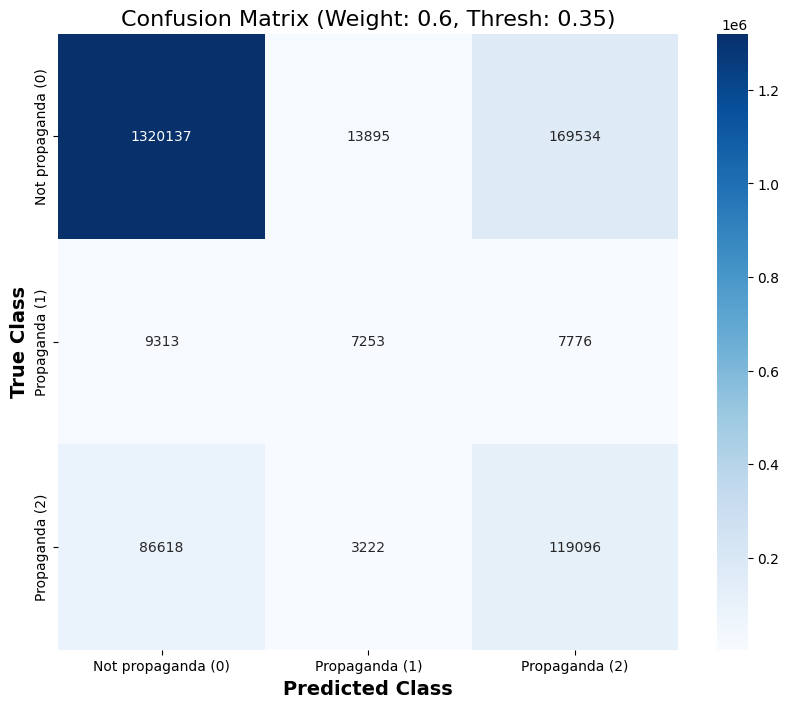


Error analysis:
🔹 Real text (0) that was mistakenly labeled as propaganda (False Positives): 183429 characters
🔹 Real propaganda (1+2) that the model missed (False Negatives): 95931 characters
🔹 Confusion between propaganda classes themselves (1 labeled as 2, or 2 labeled as 1): 10998 characters


In [4]:
best_f1 = 0
best_weight = 0
best_threshold = 0
best_prec = 0
best_rec = 0

print("\n🔍 Starting Grid Search for the best parameters...")

for w_rob in np.arange(0.1, 1.0, 0.1):
    w_ele = 1.0 - w_rob
    
    ensembled_probs = (p_rob * w_rob) + (p_ele * w_ele)    
    prob_is_propaganda = ensembled_probs[:, 1] + ensembled_probs[:, 2]
    
    for threshold in np.arange(0.1, 0.9, 0.05):
        preds = np.zeros_like(y_true)        
        propaganda_mask = prob_is_propaganda > threshold
        preds[propaganda_mask] = np.argmax(ensembled_probs[propaganda_mask, 1:], axis=1) + 1
        
        prec = precision_score(y_true, preds, labels=[1, 2], average="micro", zero_division=0)
        rec = recall_score(y_true, preds, labels=[1, 2], average="micro", zero_division=0)
        f1 = f1_score(y_true, preds, labels=[1, 2], average="micro", zero_division=0)
        
        if f1 > best_f1:
            best_f1 = f1
            best_weight = w_rob
            best_threshold = threshold
            best_prec = prec
            best_rec = rec 

print("\n" + "="*40)
print("🏆 IDEAL PARAMETERS FOUND 🏆")
print("="*40)
print(f"🥇 Best Symbolic F1 Score: {best_f1:.4f}")
print(f"🎯 Symbolic Precision: {best_prec:.4f}")
print(f"🔍 Symbolic Recall: {best_rec:.4f}")
print(f"⚖️ Optimal weights: RoBERTa = {best_weight:.1f} | ELECTRA = {1-best_weight:.1f}")
print(f"🎚️ Best cut-off threshold: {best_threshold:.2f}")
print("="*40)

print("\n📊 Generating a confusion matrix for the best parameters...")

ensembled_probs = (p_rob * best_weight) + (p_ele * (1.0 - best_weight))
prob_is_propaganda = ensembled_probs[:, 1] + ensembled_probs[:, 2]

final_preds = np.zeros_like(y_true)
propaganda_mask = prob_is_propaganda > best_threshold
final_preds[propaganda_mask] = np.argmax(ensembled_probs[propaganda_mask, 1:], axis=1) + 1

cm = confusion_matrix(y_true, final_preds, labels=[0, 1, 2])

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not propaganda (0)', 'Propaganda (1)', 'Propaganda (2)'],
            yticklabels=['Not propaganda (0)', 'Propaganda (1)', 'Propaganda (2)'])

plt.ylabel('True Class', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Class', fontsize=14, fontweight='bold')
plt.title(f'Confusion Matrix (Weight: {best_weight:.1f}, Thresh: {best_threshold:.2f})', fontsize=16)
plt.show()

print("\nError analysis:")
print(f"🔹 Real text (0) that was mistakenly labeled as propaganda (False Positives): {cm[0, 1] + cm[0, 2]} characters")
print(f"🔹 Real propaganda (1+2) that the model missed (False Negatives): {cm[1, 0] + cm[2, 0]} characters")
print(f"🔹 Confusion between propaganda classes themselves (1 labeled as 2, or 2 labeled as 1): {cm[1, 2] + cm[2, 1]} characters")


4 scenarios for comparison...



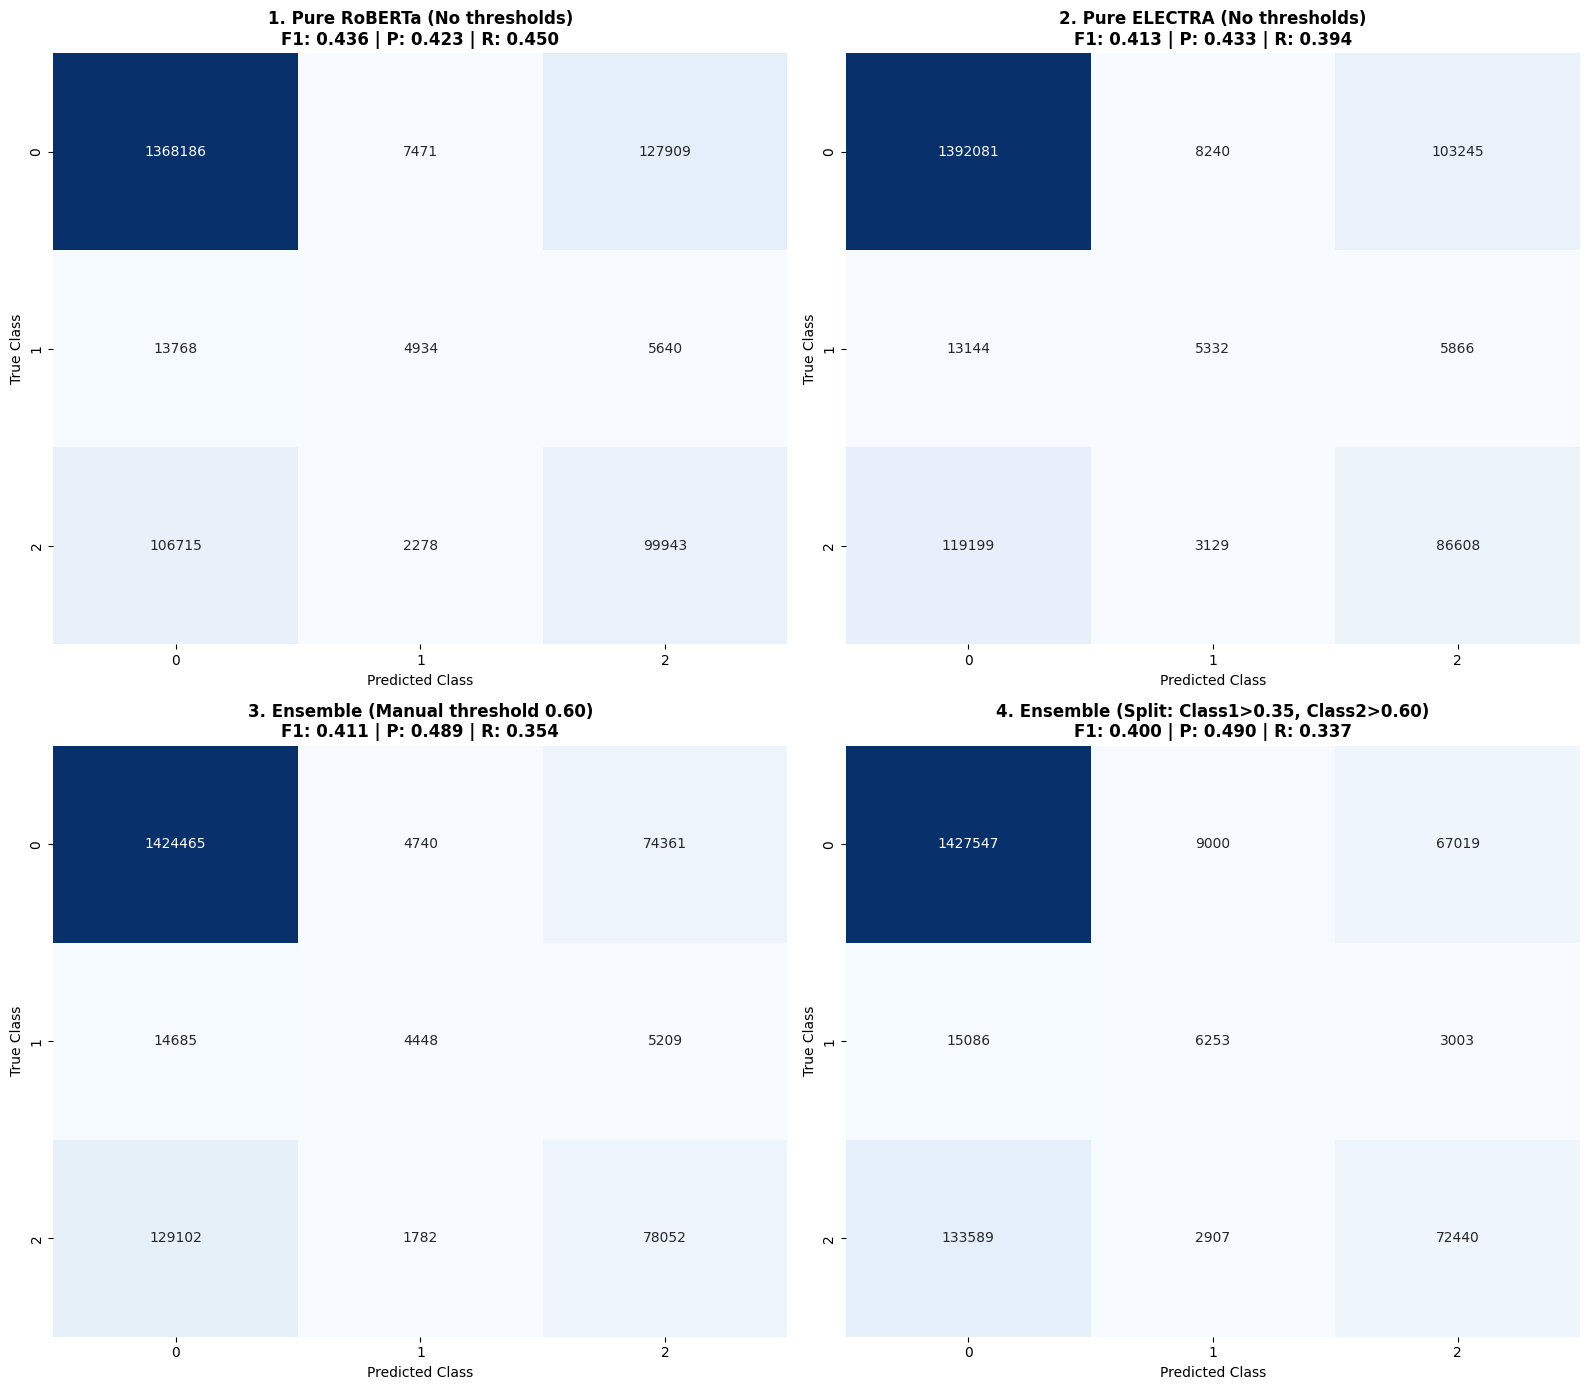

In [5]:
print("\n4 scenarios for comparison...\n")

preds_rob = np.argmax(p_rob, axis=1)
preds_ele = np.argmax(p_ele, axis=1)

weight_rob = best_weight 
ensembled_probs = (p_rob * weight_rob) + (p_ele * (1.0 - weight_rob))

prob_is_propaganda = ensembled_probs[:, 1] + ensembled_probs[:, 2]
preds_manual = np.zeros_like(y_true)
mask_manual = prob_is_propaganda > 0.60
preds_manual[mask_manual] = np.argmax(ensembled_probs[mask_manual, 1:], axis=1) + 1

preds_split = np.zeros_like(y_true)

mask1 = ensembled_probs[:, 1] > 0.35
mask2 = ensembled_probs[:, 2] > 0.60

preds_split[mask1] = 1
preds_split[mask2] = 2

overlap = mask1 & mask2
preds_split[overlap] = np.argmax(ensembled_probs[overlap, 1:], axis=1) + 1

def evaluate_and_plot(y_true, y_pred, ax, title):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
                xticklabels=['0', '1', '2'], yticklabels=['0', '1', '2'])
    
    prec = precision_score(y_true, y_pred, labels=[1, 2], average="micro", zero_division=0)
    rec = recall_score(y_true, y_pred, labels=[1, 2], average="micro", zero_division=0)
    f1 = f1_score(y_true, y_pred, labels=[1, 2], average="micro", zero_division=0)
    
    ax.set_title(f"{title}\nF1: {f1:.3f} | P: {prec:.3f} | R: {rec:.3f}", fontsize=12, fontweight='bold')
    ax.set_ylabel('True Class')
    ax.set_xlabel('Predicted Class')
    return f1, prec, rec

fig, axes = plt.subplots(2, 2, figsize=(16, 14))

evaluate_and_plot(y_true, preds_rob, axes[0, 0], "1. Pure RoBERTa (No thresholds)")
evaluate_and_plot(y_true, preds_ele, axes[0, 1], "2. Pure ELECTRA (No thresholds)")
evaluate_and_plot(y_true, preds_manual, axes[1, 0], "3. Ensemble (Manual threshold 0.60)")
evaluate_and_plot(y_true, preds_split, axes[1, 1], "4. Ensemble (Split: Class1>0.35, Class2>0.60)")

plt.tight_layout()
plt.show()


5 BEST SETTINGS FOR THE APP
#1 | RoBERTa weight: 0.6 | Thresholds: [Class1 > 0.50, Class2 > 0.55]
    🎯 Precision: 0.4874  |  🔍 Recall: 0.3648  |  ⚖️ F0.5: 0.4567

#2 | RoBERTa weight: 0.6 | Thresholds: [Class1 > 0.60, Class2 > 0.55]
    🎯 Precision: 0.4899  |  🔍 Recall: 0.3592  |  ⚖️ F0.5: 0.4566

#3 | RoBERTa weight: 0.6 | Thresholds: [Class1 > 0.55, Class2 > 0.55]
    🎯 Precision: 0.4887  |  🔍 Recall: 0.3615  |  ⚖️ F0.5: 0.4566

#4 | RoBERTa weight: 0.6 | Thresholds: [Class1 > 0.45, Class2 > 0.55]
    🎯 Precision: 0.4851  |  🔍 Recall: 0.3685  |  ⚖️ F0.5: 0.4562

#5 | RoBERTa weight: 0.7 | Thresholds: [Class1 > 0.55, Class2 > 0.55]
    🎯 Precision: 0.4816  |  🔍 Recall: 0.3741  |  ⚖️ F0.5: 0.4554


📊 Drawing confusion matrices for TOP variants...


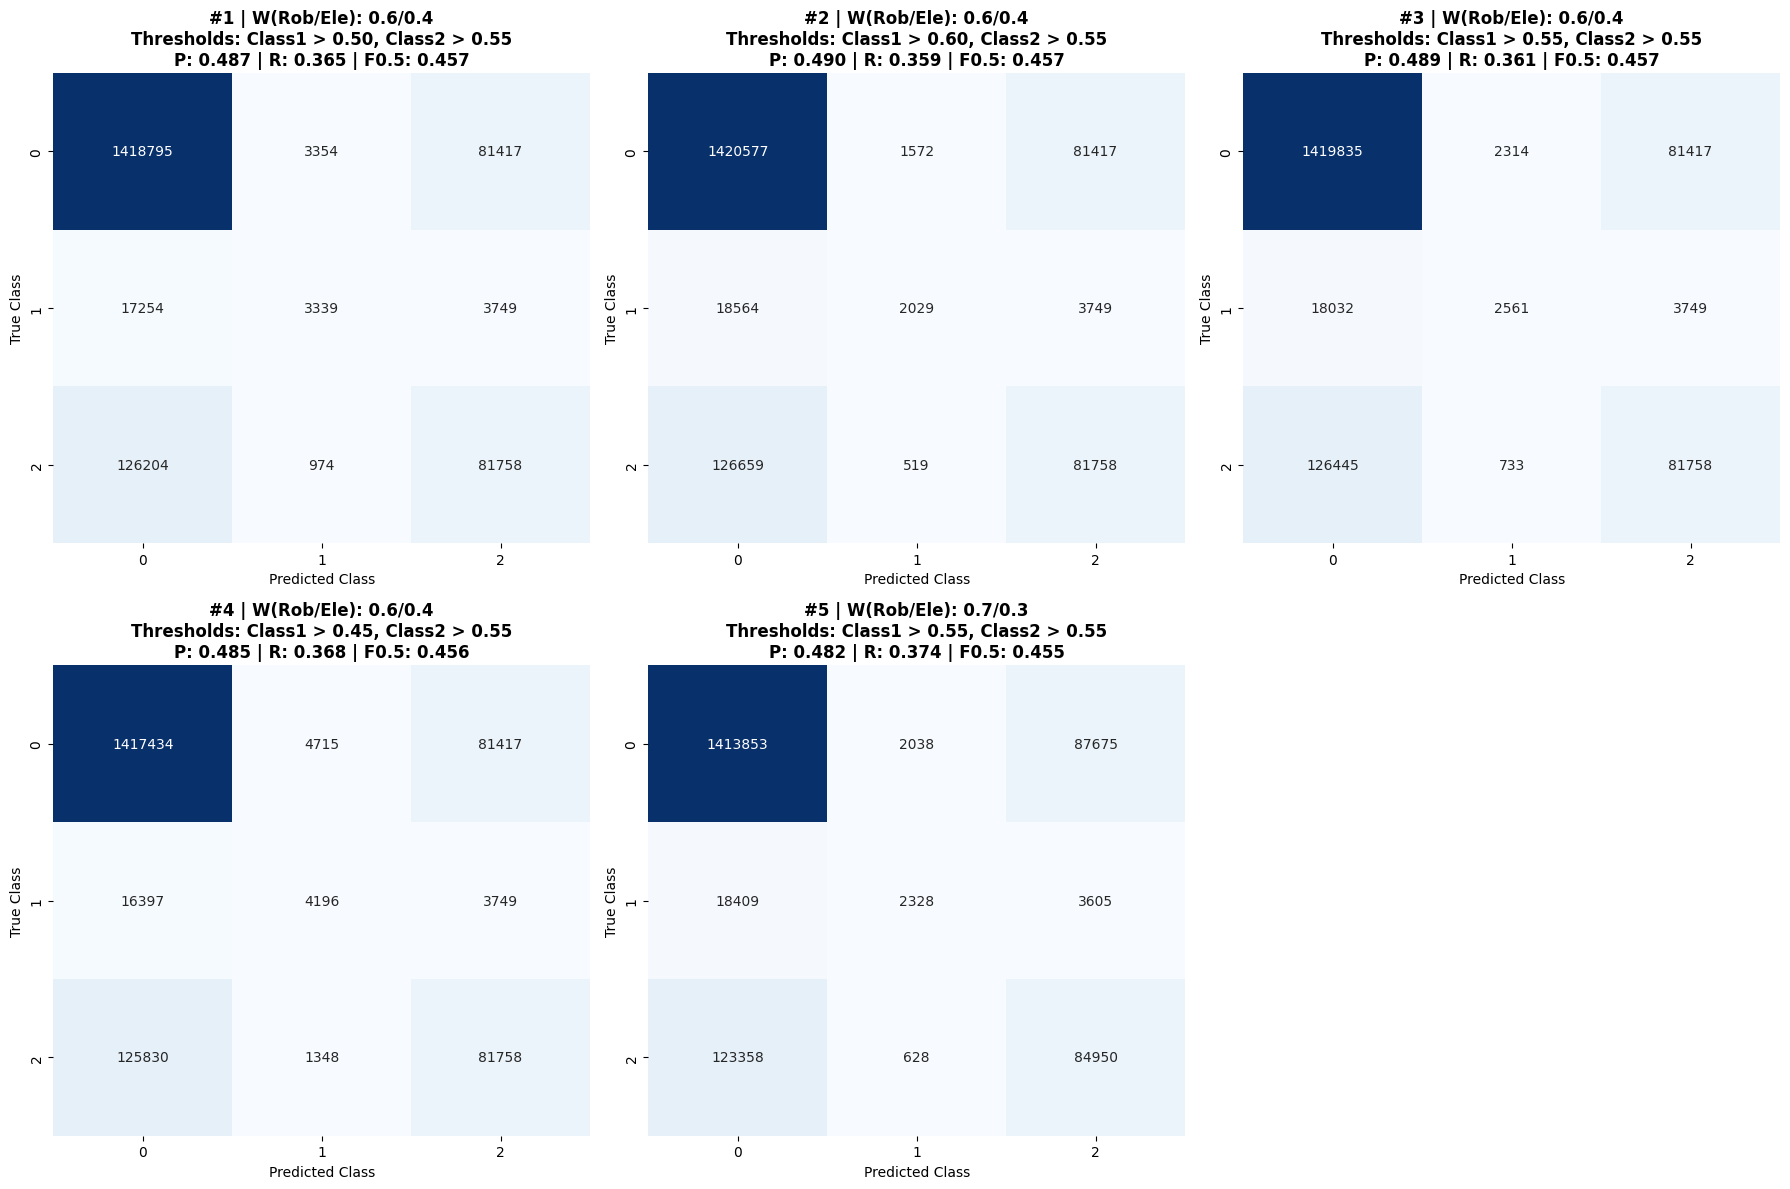

In [6]:
results = []

for w_rob in np.arange(0.1, 1.0, 0.1):
    w_ele = 1.0 - w_rob
    ensembled_probs = (p_rob * w_rob) + (p_ele * w_ele)    
    
    for thresh1 in np.arange(0.3, 0.65, 0.05):
        for thresh2 in np.arange(0.5, 0.85, 0.05):
            
            preds = np.zeros_like(y_true)
            
            mask1 = ensembled_probs[:, 1] > thresh1
            mask2 = ensembled_probs[:, 2] > thresh2
            
            preds[mask1] = 1
            preds[mask2] = 2
            
            overlap = mask1 & mask2
            preds[overlap] = np.argmax(ensembled_probs[overlap, 1:], axis=1) + 1
            
            prec = precision_score(y_true, preds, labels=[1, 2], average="micro", zero_division=0)
            rec = recall_score(y_true, preds, labels=[1, 2], average="micro", zero_division=0)
            f05 = fbeta_score(y_true, preds, beta=0.5, labels=[1, 2], average="micro", zero_division=0)
            
            if prec >= 0.48:
                results.append({
                    "w_rob": w_rob, "t1": thresh1, "t2": thresh2, 
                    "prec": prec, "rec": rec, "f05": f05
                })

results = sorted(results, key=lambda x: x["f05"], reverse=True)

print("\n" + "="*50)
print("5 BEST SETTINGS FOR THE APP")
print("="*50)
if len(results) == 0:
    print("⚠️ No combination achieved Precision >= 0.48.")
else:
    for i, res in enumerate(results[:5]):
        print(f"#{i+1} | RoBERTa weight: {res['w_rob']:.1f} | Thresholds: [Class1 > {res['t1']:.2f}, Class2 > {res['t2']:.2f}]")
        print(f"    🎯 Precision: {res['prec']:.4f}  |  🔍 Recall: {res['rec']:.4f}  |  ⚖️ F0.5: {res['f05']:.4f}\n")
print("="*50)

if len(results) > 0:
    print("\n📊 Drawing confusion matrices for TOP variants...")
    
    n_plots = min(5, len(results))
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    axes = axes.flatten() 
    
    for i, res in enumerate(results[:n_plots]):
        ax = axes[i]
        
        w_rob = res['w_rob']
        w_ele = 1.0 - w_rob
        thresh1 = res['t1']
        thresh2 = res['t2']
        
        ensembled_probs = (p_rob * w_rob) + (p_ele * w_ele)
        
        preds = np.zeros_like(y_true)
        mask1 = ensembled_probs[:, 1] > thresh1
        mask2 = ensembled_probs[:, 2] > thresh2
        
        preds[mask1] = 1
        preds[mask2] = 2
        
        overlap = mask1 & mask2
        preds[overlap] = np.argmax(ensembled_probs[overlap, 1:], axis=1) + 1
        
        cm = confusion_matrix(y_true, preds, labels=[0, 1, 2])
        
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
                    xticklabels=['0', '1', '2'], yticklabels=['0', '1', '2'])
        
        title = (f"#{i+1} | W(Rob/Ele): {w_rob:.1f}/{w_ele:.1f}\n"
                 f"Thresholds: Class1 > {thresh1:.2f}, Class2 > {thresh2:.2f}\n"
                 f"P: {res['prec']:.3f} | R: {res['rec']:.3f} | F0.5: {res['f05']:.3f}")
        ax.set_title(title, fontsize=12, fontweight='bold')
        ax.set_ylabel('True Class')
        ax.set_xlabel('Predicted Class')
        
    for j in range(n_plots, len(axes)):
        fig.delaxes(axes[j])
        
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ No results to draw matrices for (Precision is too low).")


✨ Applying Post-processing (Pseudo-CRF) to the best thresholds...
🎯 Precision AFTER cleaning: 0.4896 (Was: 0.487)
🔍 Recall AFTER cleaning: 0.3058 (Was: 0.365)
⚖️ F0.5 AFTER cleaning: 0.4370


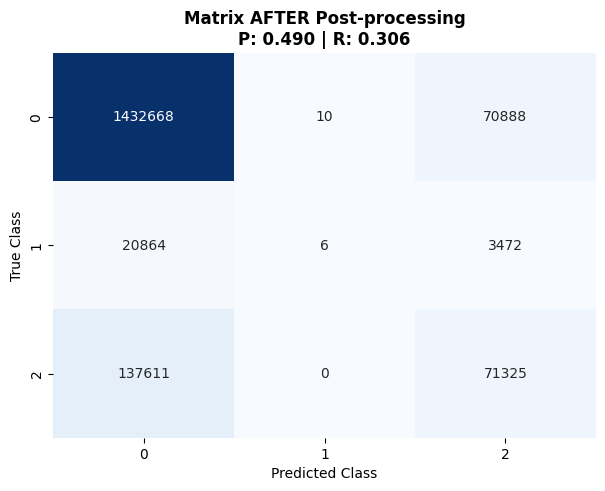


✨ Applying ONLY Soft Merging (Soft Merge <= 2 characters)...
🎯 Precision AFTER merging: 0.4869
🔍 Recall AFTER merging: 0.3659
⚖️ F0.5 AFTER merging: 0.4567


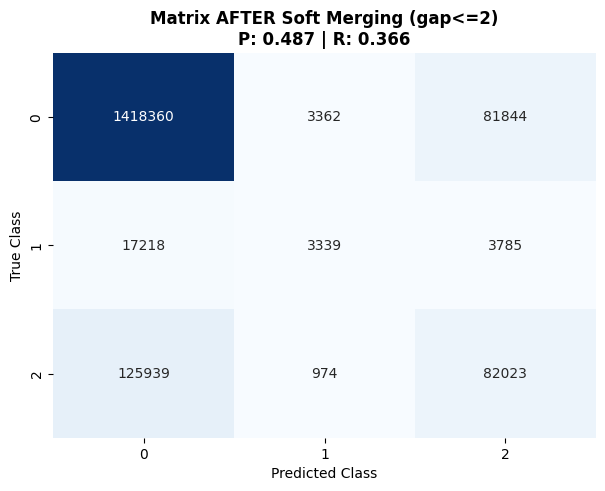

In [7]:
def apply_pseudo_crf(preds_array, min_length=12, merge_gap=4):
    cleaned = preds_array.copy()
    n = len(cleaned)
    
    last_class = 0
    last_class_idx = -1
    
    for i in range(n):
        current = cleaned[i]
        if current != 0:
            if current == last_class and (i - last_class_idx) <= merge_gap:
                cleaned[last_class_idx:i] = current 
            last_class = current
            last_class_idx = i

    current_class = 0
    start_idx = 0
    
    for i in range(n + 1):
        if i == n or cleaned[i] != current_class:
            if current_class != 0:
                length = i - start_idx
                if length < min_length:
                    cleaned[start_idx:i] = 0 
            if i < n:
                current_class = cleaned[i]
                start_idx = i
                
    return cleaned

def soft_merge_spans(preds_array, merge_gap=2):
    cleaned = preds_array.copy()
    n = len(cleaned)
    
    last_class = 0
    last_class_idx = -1
    
    for i in range(n):
        current = cleaned[i]
        if current != 0:
            gap_size = i - last_class_idx - 1
            if current == last_class and gap_size > 0 and gap_size <= merge_gap:
                cleaned[(last_class_idx + 1):i] = current 
            last_class = current
            last_class_idx = i
                
    return cleaned

print("\n✨ Applying Post-processing (Pseudo-CRF) to the best thresholds...")

w_rob = 0.6
w_ele = 0.4
thresh1 = 0.50
thresh2 = 0.55

ensembled_probs = (p_rob * w_rob) + (p_ele * w_ele)
raw_preds = np.zeros_like(y_true)

mask1 = ensembled_probs[:, 1] > thresh1
mask2 = ensembled_probs[:, 2] > thresh2
raw_preds[mask1] = 1
raw_preds[mask2] = 2
overlap = mask1 & mask2
raw_preds[overlap] = np.argmax(ensembled_probs[overlap, 1:], axis=1) + 1

cleaned_preds = apply_pseudo_crf(raw_preds, min_length=15, merge_gap=4)

cm_clean = confusion_matrix(y_true, cleaned_preds, labels=[0, 1, 2])
prec_clean = precision_score(y_true, cleaned_preds, labels=[1, 2], average="micro", zero_division=0)
rec_clean = recall_score(y_true, cleaned_preds, labels=[1, 2], average="micro", zero_division=0)
f05_clean = fbeta_score(y_true, cleaned_preds, beta=0.5, labels=[1, 2], average="micro", zero_division=0)

print("="*50)
print(f"🎯 Precision AFTER cleaning: {prec_clean:.4f} (Was: 0.487)")
print(f"🔍 Recall AFTER cleaning: {rec_clean:.4f} (Was: 0.365)")
print(f"⚖️ F0.5 AFTER cleaning: {f05_clean:.4f}")
print("="*50)

plt.figure(figsize=(7, 5))
sns.heatmap(cm_clean, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['0', '1', '2'], yticklabels=['0', '1', '2'])
plt.title(f"Matrix AFTER Post-processing\nP: {prec_clean:.3f} | R: {rec_clean:.3f}", fontweight='bold')
plt.ylabel('True Class')
plt.xlabel('Predicted Class')
plt.show()

print("\n✨ Applying ONLY Soft Merging (Soft Merge <= 2 characters)...")

merged_preds = soft_merge_spans(raw_preds, merge_gap=2)

cm_merged = confusion_matrix(y_true, merged_preds, labels=[0, 1, 2])
prec_merged = precision_score(y_true, merged_preds, labels=[1, 2], average="micro", zero_division=0)
rec_merged = recall_score(y_true, merged_preds, labels=[1, 2], average="micro", zero_division=0)
f05_merged = fbeta_score(y_true, merged_preds, beta=0.5, labels=[1, 2], average="micro", zero_division=0)

print("="*50)
print(f"🎯 Precision AFTER merging: {prec_merged:.4f}")
print(f"🔍 Recall AFTER merging: {rec_merged:.4f}")
print(f"⚖️ F0.5 AFTER merging: {f05_merged:.4f}")
print("="*50)

plt.figure(figsize=(7, 5))
sns.heatmap(cm_merged, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['0', '1', '2'], yticklabels=['0', '1', '2'])
plt.title(f"Matrix AFTER Soft Merging (gap<=2)\nP: {prec_merged:.3f} | R: {rec_merged:.3f}", fontweight='bold')
plt.ylabel('True Class')
plt.xlabel('Predicted Class')
plt.show()


🔍 LOADING ORIGINAL TEXT FOR WORD BOUNDARY ANALYSIS...

📝 FRAGMENTATION ANALYSIS FOR ARTICLE: article111111111
--------------------------------------------------
❌ Broken word: 'between'
   Characters: ['b', 'e', 't', 'w', 'e', 'e', 'n']
   Classes:    [0, 0, 2, 2, 0, 0, 0]
❌ Broken word: 'and'
   Characters: ['a', 'n', 'd']
   Classes:    [0, 0, 2]
❌ Broken word: 'every'
   Characters: ['e', 'v', 'e', 'r', 'y']
   Classes:    [2, 0, 0, 0, 0]
❌ Broken word: 'and'
   Characters: ['a', 'n', 'd']
   Classes:    [2, 0, 0]
❌ Broken word: 'over'
   Characters: ['o', 'v', 'e', 'r']
   Classes:    [2, 2, 2, 0]
❌ Broken word: 'had'
   Characters: ['h', 'a', 'd']
   Classes:    [0, 0, 2]
❌ Broken word: 'helped'
   Characters: ['h', 'e', 'l', 'p', 'e', 'd']
   Classes:    [2, 2, 2, 0, 0, 0]
❌ Broken word: 'causes'
   Characters: ['c', 'a', 'u', 's', 'e', 's']
   Classes:    [0, 0, 0, 2, 2, 2]
❌ Broken word: 'plague'
   Characters: ['p', 'l', 'a', 'g', 'u', 'e']
   Classes:    [2, 0, 0, 0, 0, 0]
-

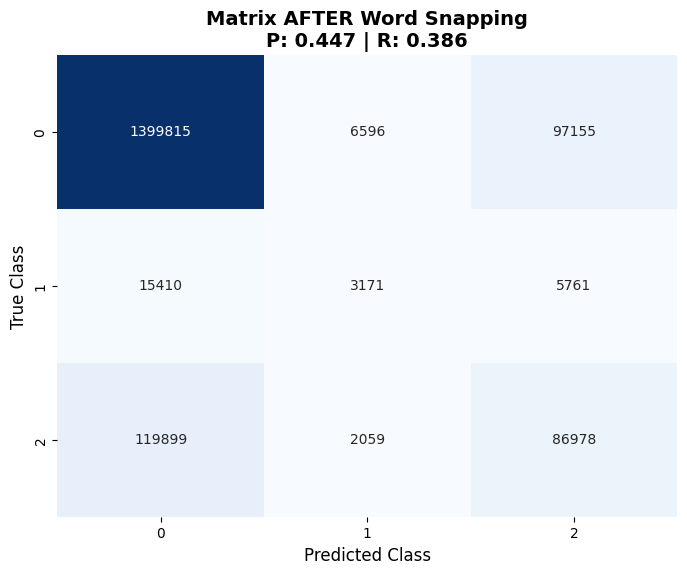

In [8]:
import json
import re

print("\n🔍 LOADING ORIGINAL TEXT FOR WORD BOUNDARY ANALYSIS...")
with open('../data/processed/si_dataset.json', 'r', encoding='utf-8') as f:
    orig_data = json.load(f)
text_dict = {item['article_id']: item['text'] for item in orig_data}

sample_art = unique_articles[0]
start_idx, end_idx = article_char_bounds[sample_art]
sample_text = text_dict[sample_art]
sample_preds = raw_preds[start_idx:end_idx]

print(f"\n📝 FRAGMENTATION ANALYSIS FOR ARTICLE: {sample_art}")
print("-" * 50)

for match in re.finditer(r'\b\w+\b', sample_text):
    word_start = match.start()
    word_end = match.end()
    
    if word_end <= len(sample_preds):
        word_preds = sample_preds[word_start:word_end]
        unique_preds = np.unique(word_preds)
        
        if len(unique_preds) > 1:
            print(f"❌ Broken word: '{match.group()}'")
            print(f"   Characters: {list(match.group())}")
            print(f"   Classes:    {word_preds.tolist()}")
            
print("-" * 50)

def snap_to_word_boundaries(text, preds_array):
    snapped_preds = preds_array.copy()
    for match in re.finditer(r'\b\w+\b', text):
        start, end = match.start(), match.end()
        if end <= len(snapped_preds):
            word_preds = snapped_preds[start:end]
            if 1 in word_preds or 2 in word_preds:
                propaganda_classes = [p for p in word_preds if p != 0]
                majority_class = max(set(propaganda_classes), key=propaganda_classes.count)
                snapped_preds[start:end] = majority_class
    return snapped_preds

print("\n✨ Applying Word Boundary Snapping to the entire dataset...")
snapped_preds_all = np.zeros_like(raw_preds)

for art_id in unique_articles:
    start_idx, end_idx = article_char_bounds[art_id]
    art_text = text_dict[art_id]
    art_preds = raw_preds[start_idx:end_idx]
    snapped_preds_all[start_idx:end_idx] = snap_to_word_boundaries(art_text, art_preds)

prec_snap = precision_score(y_true, snapped_preds_all, labels=[1, 2], average="micro", zero_division=0)
rec_snap = recall_score(y_true, snapped_preds_all, labels=[1, 2], average="micro", zero_division=0)
f05_snap = fbeta_score(y_true, snapped_preds_all, beta=0.5, labels=[1, 2], average="micro", zero_division=0)

print("="*50)
print(f"🎯 Precision AFTER Word Snapping: {prec_snap:.4f}")
print(f"🔍 Recall AFTER Word Snapping: {rec_snap:.4f}")
print(f"⚖️ F0.5 AFTER Word Snapping: {f05_snap:.4f}")
print("="*50)

print("\n📊 Drawing confusion matrix for Word Snapping...")
cm_snap = confusion_matrix(y_true, snapped_preds_all, labels=[0, 1, 2])

plt.figure(figsize=(8, 6))
sns.heatmap(cm_snap, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['0', '1', '2'], yticklabels=['0', '1', '2'])
plt.title(f"Matrix AFTER Word Snapping\nP: {prec_snap:.3f} | R: {rec_snap:.3f}", fontsize=14, fontweight='bold')
plt.ylabel('True Class', fontsize=12)
plt.xlabel('Predicted Class', fontsize=12)
plt.show()